# Pooling Strategy Experiment

It compares:

- mean pooling only
- masked mean pooling with masked max pooling concatenated

Everything else stays aligned with Sang-Young's proposed architecture.


In [1]:
!pip -q install statsmodels scikit-learn pandas tqdm seaborn

In [2]:
import os
import csv
import math
import time
import copy
import json
import random
import unicodedata
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.cuda.amp import autocast, GradScaler

from google.colab import drive
drive.mount('/content/drive')


/Users/aryamandev/.pyenv/versions/3.11.6/lib/python3.11/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
@dataclass
class CFG:
    train_path: str = "/content/drive/MyDrive/Penn State/tatoeba_audit_output/cleaned_preserve_counts/sentences.top10langs.train.cleaned.tsv"
    dev_path: str = "/content/drive/MyDrive/Penn State/tatoeba_audit_output/cleaned_preserve_counts/sentences.top10langs.dev.cleaned.tsv"

    # set to Sang-Young's proposed architecture design
    embed_dim: int = 64
    hidden_size: int = 256
    num_layers: int = 2
    gru_dropout: float = 0.3
    classifier_dropout: float = 0.5

    # training parameters. for code test set to epochs: int = 5, hypothesis-test set to epochs: int = 15
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 5
    patience: int = 3
    grad_clip: float = 1.0

    # evaluation / reproducibility. for code test set to seed: tuple = (42,), hypothesis-test set to seed: tuple = (13, 42, 123)
    seeds: tuple = (42,)
    num_workers: int = 2

    # the max length chosen to match my earlier dataset analysis
    max_len: int = 128

    # the pooling variants we're testing
    pooling_variants: tuple = ("mean", "mean_max")


cfg = CFG()
print(asdict(cfg))


{'train_path': '/content/drive/MyDrive/Penn State/tatoeba_audit_output/cleaned_preserve_counts/sentences.top10langs.train.cleaned.tsv', 'dev_path': '/content/drive/MyDrive/Penn State/tatoeba_audit_output/cleaned_preserve_counts/sentences.top10langs.dev.cleaned.tsv', 'embed_dim': 64, 'hidden_size': 256, 'num_layers': 2, 'gru_dropout': 0.3, 'classifier_dropout': 0.5, 'batch_size': 64, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 5, 'patience': 3, 'grad_clip': 1.0, 'seeds': (42,), 'num_workers': 2, 'max_len': 128, 'pooling_variants': ('mean', 'mean_max')}


In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


device = get_device()
print("Device:", device)


Device: cpu


In [ ]:
def load_tsv(path: str) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["label", "text"],
        dtype=str,
        keep_default_na=False,
        quoting=csv.QUOTE_NONE,
        engine="python",
        on_bad_lines="skip",
    )

    # if present, this instructs it to drop the accidental header row
    if len(df) > 0:
        first_label = str(df.iloc[0]["label"]).strip().lower()
        first_text = str(df.iloc[0]["text"]).strip().lower()
        header_like_labels = {"label", "lang", "language", "code", "iso"}
        header_like_texts = {"text", "sentence", "sentences"}
        if first_label in header_like_labels or first_text in header_like_texts:
            df = df.iloc[1:].reset_index(drop=True)

    df["label"] = df["label"].astype(str).str.strip()
    df["text"] = df["text"].astype(str).apply(lambda s: unicodedata.normalize("NFC", s))

    # this instructs it to only keep the non-empty rows
    df = df[(df["label"] != "") & (df["text"] != "")]
    df = df.reset_index(drop=True)
    return df


train_df = load_tsv(cfg.train_path)
dev_df = load_tsv(cfg.dev_path)

print("Train Shape:", train_df.shape)
print("Dev shape:", dev_df.shape)

print("\nTrain Label Counts:")
print(train_df["label"].value_counts().sort_index())

print("\nDev Label Counts:")
print(dev_df["label"].value_counts().sort_index())


Train Shape: (100000, 2)
Dev shape: (10000, 2)

Train Label Counts:
label
ber    10000
deu    10000
eng    10000
epo    10000
fra    10000
hun    10000
ita    10000
por    10000
spa    10000
tur    10000
Name: count, dtype: int64

Dev Label Counts:
label
ber    1000
deu    1000
eng    1000
epo    1000
fra    1000
hun    1000
ita    1000
por    1000
spa    1000
tur    1000
Name: count, dtype: int64



=== TRAIN LENGTH STATS ===
Median Chars: 33.0
95th Percentile Chars: 74.0
99th Percentile Chars: 128.0
Max Chars: 804
Median Words: 6.0
95th Percentile Words: 13.0
99th Percentile Words: 21.0
Max Words: 141

=== DEV LENGTH STATS ===
Median Chars: 33.0
95th Percentile Chars: 75.0
99th Percentile Chars: 124.0
Max Chars: 512
Median Words: 6.0
95th Percentile Words: 13.0
99th Percentile Words: 21.0
Max Words: 91


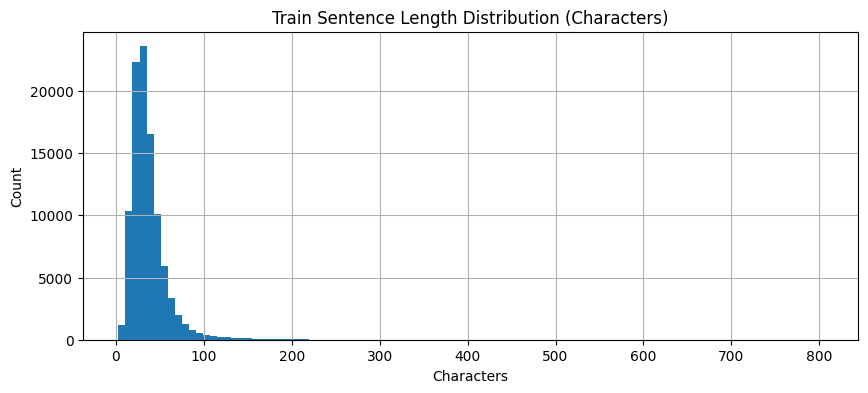

In [ ]:
def describe_lengths(df: pd.DataFrame, split_name: str):
    char_lens = df["text"].str.len()
    word_lens = df["text"].str.split().str.len()

    print(f"\n=== {split_name.upper()} LENGTH STATS ===")
    print(f"Median Chars: {char_lens.median():.1f}")
    print(f"95th Percentile Chars: {char_lens.quantile(0.95):.1f}")
    print(f"99th Percentile Chars: {char_lens.quantile(0.99):.1f}")
    print(f"Max Chars: {char_lens.max()}")
    print(f"Median Words: {word_lens.median():.1f}")
    print(f"95th Percentile Words: {word_lens.quantile(0.95):.1f}")
    print(f"99th Percentile Words: {word_lens.quantile(0.99):.1f}")
    print(f"Max Words: {word_lens.max()}")


describe_lengths(train_df, "train")
describe_lengths(dev_df, "dev")

# serves as an optional visual check
plt.figure(figsize=(10, 4))
train_df["text"].str.len().hist(bins=100)
plt.title("Train Sentence Length Distribution (Characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()


In [ ]:
labels = sorted(train_df["label"].unique())
label2id = {lab: i for i, lab in enumerate(labels)}
id2label = {i: lab for lab, i in label2id.items()}

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1

char_counter = Counter()
for text in train_df["text"]:
    char_counter.update(list(text))

itos = [PAD_TOKEN, UNK_TOKEN] + sorted(char_counter.keys())
stoi = {ch: i for i, ch in enumerate(itos)}

print("Number of Labels:", len(labels))
print("Labels:", labels)
print("Character Vocabulary Size:", len(itos))
print("A Few Example Characters:", itos[:30])


Number of Labels: 10
Labels: ['ber', 'deu', 'eng', 'epo', 'fra', 'hun', 'ita', 'por', 'spa', 'tur']
Character Vocabulary Size: 230
A Few Example Characters: ['<PAD>', '<UNK>', ' ', '!', '"', '$', '%', '&', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '>']


In [ ]:
class CharLanguageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, stoi: dict, label2id: dict, max_len: int):
        self.df = df.reset_index(drop=True)
        self.stoi = stoi
        self.label2id = label2id
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode_text(self, text: str):
        chars = list(text)[:self.max_len]
        ids = [self.stoi.get(ch, UNK_IDX) for ch in chars]
        return torch.tensor(ids, dtype=torch.long), len(ids)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["text"]
        label = row["label"]
        input_ids, length = self.encode_text(text)
        y = self.label2id[label]
        return input_ids, length, y, text


def collate_batch(batch):
    seqs, lengths, labels_batch, raw_texts = zip(*batch)
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    lengths = torch.tensor(lengths, dtype=torch.long)
    labels_batch = torch.tensor(labels_batch, dtype=torch.long)
    return padded, lengths, labels_batch, list(raw_texts)


In [ ]:
class BiGRULanguageID(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        pad_idx: int,
        gru_dropout: float = 0.3,
        classifier_dropout: float = 0.5,
        pooling: str = "mean",
    ):
        super().__init__()
        assert pooling in {"mean", "mean_max"}

        self.pooling = pooling
        self.hidden_size = hidden_size
        self.num_directions = 2

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        rep_dim = hidden_size * self.num_directions
        if pooling == "mean_max":
            rep_dim *= 2

        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(rep_dim, num_classes)

    def masked_mean_pool(self, x, mask):
        # x: (B, T, H)
        # mask: (B, T)
        mask = mask.unsqueeze(-1).float()  # (B, T, 1)
        summed = (x * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-8)
        return summed / denom

    def masked_max_pool(self, x, mask):
        # x: (B, T, H)
        # mask: (B, T)
        mask = mask.unsqueeze(-1)  # (B, T, 1)
        x = x.masked_fill(~mask, -1e9)
        return x.max(dim=1).values

    def forward(self, input_ids, lengths):
        # input_ids: (B, T)
        emb = self.embedding(input_ids)  # (B, T, E)

        packed = pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.gru(packed)
        out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=input_ids.size(1),
        )  # (B, T, 2H)

        # sets true for valid time steps, false for padding
        time_ids = torch.arange(input_ids.size(1), device=lengths.device).unsqueeze(0)
        mask = time_ids < lengths.unsqueeze(1)  # (B, T)

        mean_rep = self.masked_mean_pool(out, mask)

        if self.pooling == "mean":
            rep = mean_rep
        else:
            max_rep = self.masked_max_pool(out, mask)
            rep = torch.cat([mean_rep, max_rep], dim=-1)

        logits = self.classifier(self.dropout(rep))
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_texts = []

    for input_ids, lengths, labels_batch, raw_texts in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels_batch = labels_batch.to(device)

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels_batch)

        total_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(labels_batch.detach().cpu().tolist())
        all_texts.extend(raw_texts)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "texts": all_texts,
    }


In [ ]:
def train_one_run(pooling: str, seed: int, train_df: pd.DataFrame, dev_df: pd.DataFrame, cfg: CFG):
    seed_everything(seed)

    train_dataset = CharLanguageDataset(train_df, stoi, label2id, cfg.max_len)
    dev_dataset = CharLanguageDataset(dev_df, stoi, label2id, cfg.max_len)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        collate_fn=collate_batch,
        pin_memory=(device.type == "cuda"),
        generator=g,
    )

    dev_loader = DataLoader(
        dev_dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        collate_fn=collate_batch,
        pin_memory=(device.type == "cuda"),
    )

    model = BiGRULanguageID(
        vocab_size=len(itos),
        embed_dim=cfg.embed_dim,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        num_classes=len(labels),
        pad_idx=PAD_IDX,
        gru_dropout=cfg.gru_dropout,
        classifier_dropout=cfg.classifier_dropout,
        pooling=pooling,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )
    scaler = GradScaler(enabled=(device.type == "cuda"))

    history = defaultdict(list)
    best_metric = -1.0
    best_epoch = -1
    best_state = None
    best_eval = None
    patience_counter = 0

    print(f"\n{'=' * 80}")
    print(f"Starting run | pooling={pooling} | seed={seed}")
    print(f"Trainable params: {count_parameters(model):,}")
    print(f"{'=' * 80}")

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"[{pooling} | seed={seed}] Epoch {epoch}/{cfg.epochs}", leave=False)
        for input_ids, lengths, labels_batch, _ in pbar:
            input_ids = input_ids.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(device.type == "cuda")):
                logits = model(input_ids, lengths)
                loss = criterion(logits, labels_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * input_ids.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(train_loader.dataset)
        dev_metrics = evaluate_model(model, dev_loader, criterion, device)

        # sets manual LR-change message logging after dev_metrics is computed
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(dev_metrics["macro_f1"])
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr != old_lr:
            print(f"Learning rate reduced: {old_lr:.6g} -> {new_lr:.6g}")

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_metrics["loss"])
        history["dev_accuracy"].append(dev_metrics["accuracy"])
        history["dev_macro_f1"].append(dev_metrics["macro_f1"])

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"dev_loss={dev_metrics['loss']:.4f} | "
            f"dev_acc={dev_metrics['accuracy']:.4f} | "
            f"dev_macro_f1={dev_metrics['macro_f1']:.4f}"
        )

        if dev_metrics["macro_f1"] > best_metric:
            best_metric = dev_metrics["macro_f1"]
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_eval = copy.deepcopy(dev_metrics)
        else:
            patience_counter += 1
            if patience_counter >= cfg.patience:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

    # restore best checkpoint
    model.load_state_dict(best_state)

    result = {
        "pooling": pooling,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_dev_loss": best_eval["loss"],
        "best_dev_accuracy": best_eval["accuracy"],
        "best_dev_macro_f1": best_eval["macro_f1"],
        "history": dict(history),
        "dev_preds": best_eval["preds"],
        "dev_labels": best_eval["labels"],
        "dev_texts": best_eval["texts"],
        "state_dict": best_state,
        "num_params": count_parameters(model),
    }
    return result


In [ ]:
all_runs = []
start_time = time.time()

for pooling in cfg.pooling_variants:
    for seed in cfg.seeds:
        run_result = train_one_run(
            pooling=pooling,
            seed=seed,
            train_df=train_df,
            dev_df=dev_df,
            cfg=cfg,
        )
        all_runs.append(run_result)

elapsed = time.time() - start_time
print(f"\nTotal experiment time: {elapsed / 60:.2f} minutes")



Starting run | pooling=mean | seed=42
Trainable params: 1,697,162


/tmp/ipykernel_2979/3900034949.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))


[mean | seed=42] Epoch 1/5:   0%|          | 0/1563 [00:00<?, ?it/s]

/tmp/ipykernel_2979/3900034949.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


Epoch 01 | train_loss=0.1870 | dev_loss=0.0513 | dev_acc=0.9829 | dev_macro_f1=0.9829


...

/tmp/ipykernel_2979/3900034949.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


Epoch 04 | train_loss=0.0198 | dev_loss=0.0323 | dev_acc=0.9917 | dev_macro_f1=0.9917


[mean_max | seed=42] Epoch 5/5:   0%|          | 0/1563 [00:00<?, ?it/s]

/tmp/ipykernel_2979/3900034949.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79538296a3e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79538296a3e0>
Traceback (most recent call last):
  File "/

Epoch 05 | train_loss=0.0165 | dev_loss=0.0340 | dev_acc=0.9914 | dev_macro_f1=0.9914

Total experiment time: 536.19 minutes


In [ ]:
results_df = pd.DataFrame([
    {
        "pooling": r["pooling"],
        "seed": r["seed"],
        "best_epoch": r["best_epoch"],
        "dev_loss": r["best_dev_loss"],
        "dev_accuracy": r["best_dev_accuracy"],
        "dev_macro_f1": r["best_dev_macro_f1"],
        "num_params": r["num_params"],
    }
    for r in all_runs
])

print("Per-run results:")
display(results_df.sort_values(["pooling", "seed"]).reset_index(drop=True))

summary_df = (
    results_df
    .groupby("pooling")
    .agg(
        runs=("seed", "count"),
        accuracy_mean=("dev_accuracy", "mean"),
        accuracy_std=("dev_accuracy", "std"),
        macro_f1_mean=("dev_macro_f1", "mean"),
        macro_f1_std=("dev_macro_f1", "std"),
        loss_mean=("dev_loss", "mean"),
        loss_std=("dev_loss", "std"),
        params=("num_params", "mean"),
    )
    .reset_index()
)

print("\nSummary across seeds:")
display(summary_df)


Per-run results:


,pooling,seed,best_epoch,dev_loss,dev_accuracy,dev_macro_f1,num_params
0,mean,42,3,0.030193,0.9907,0.990691,1697162
1,mean_max,42,4,0.032336,0.9917,0.991700,1702282



Summary across seeds:


,pooling,runs,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,loss_mean,loss_std,params
0,mean,1,0.9907,NaN,0.990691,NaN,0.030193,NaN,1697162.0
1,mean_max,1,0.9917,NaN,0.991700,NaN,0.032336,NaN,1702282.0


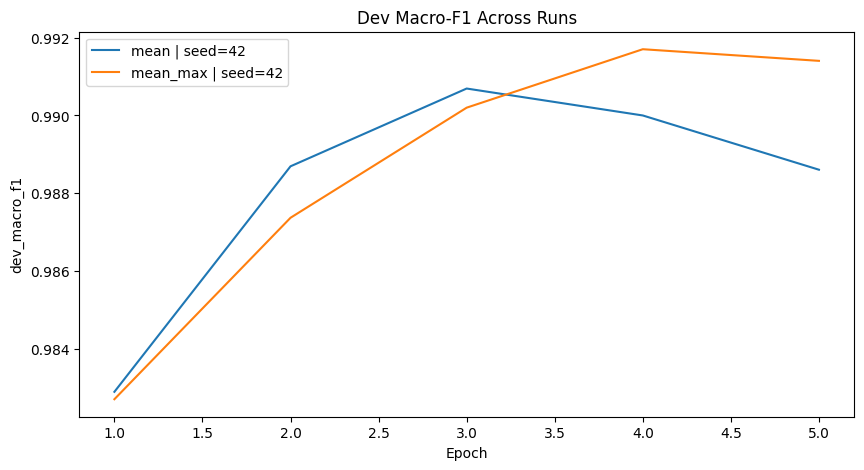

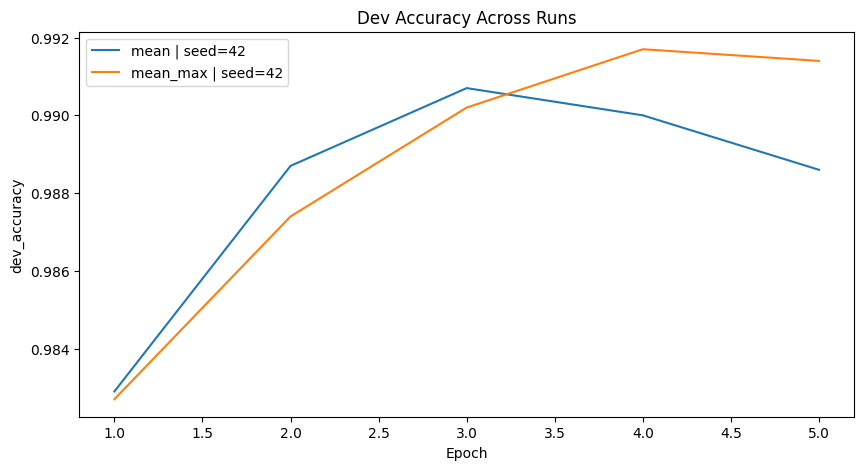

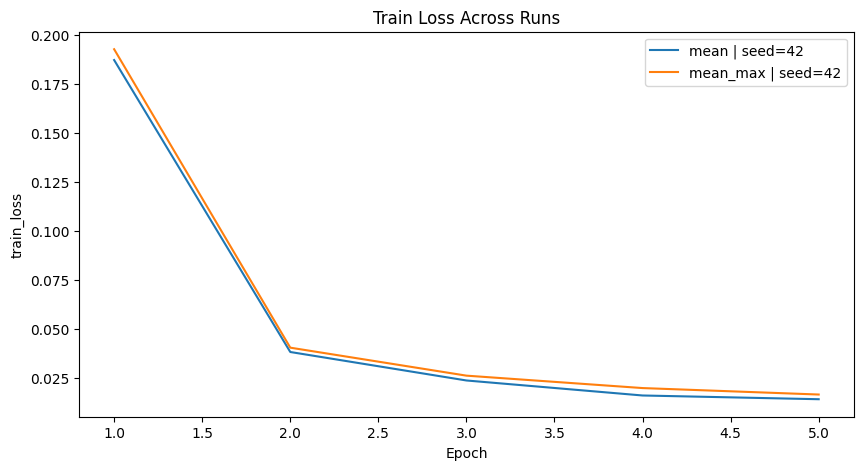

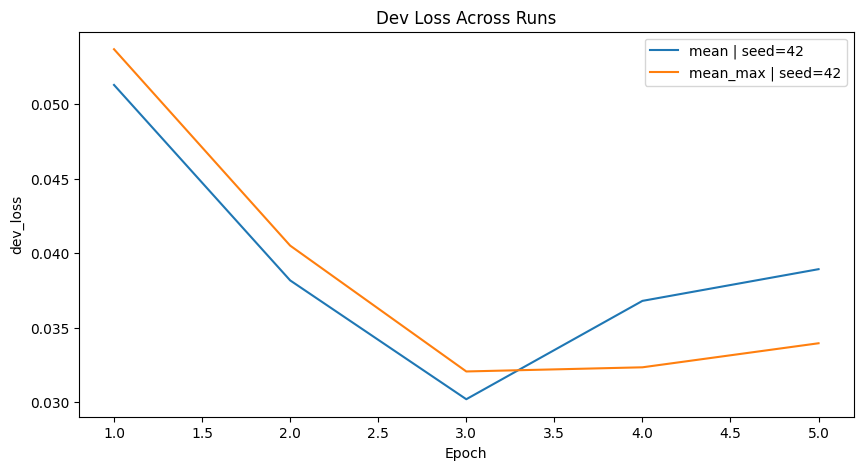

In [ ]:
def plot_histories(all_runs, metric_key, title):
    plt.figure(figsize=(10, 5))
    for run in all_runs:
        epochs = run["history"]["epoch"]
        values = run["history"][metric_key]
        plt.plot(epochs, values, label=f"{run['pooling']} | seed={run['seed']}")
    plt.xlabel("Epoch")
    plt.ylabel(metric_key)
    plt.title(title)
    plt.legend()
    plt.show()


plot_histories(all_runs, "dev_macro_f1", "Dev Macro-F1 Across Runs")
plot_histories(all_runs, "dev_accuracy", "Dev Accuracy Across Runs")
plot_histories(all_runs, "train_loss", "Train Loss Across Runs")
plot_histories(all_runs, "dev_loss", "Dev Loss Across Runs")


In [ ]:
best_mean_run = max(
    [r for r in all_runs if r["pooling"] == "mean"],
    key=lambda x: x["best_dev_macro_f1"],
)

best_mean_max_run = max(
    [r for r in all_runs if r["pooling"] == "mean_max"],
    key=lambda x: x["best_dev_macro_f1"],
)

print("Best mean-pooling run:")
print({
    "seed": best_mean_run["seed"],
    "best_epoch": best_mean_run["best_epoch"],
    "dev_accuracy": best_mean_run["best_dev_accuracy"],
    "dev_macro_f1": best_mean_run["best_dev_macro_f1"],
    "dev_loss": best_mean_run["best_dev_loss"],
    "num_params": best_mean_run["num_params"],
})

print("\nBest mean with max-pooling run:")
print({
    "seed": best_mean_max_run["seed"],
    "best_epoch": best_mean_max_run["best_epoch"],
    "dev_accuracy": best_mean_max_run["best_dev_accuracy"],
    "dev_macro_f1": best_mean_max_run["best_dev_macro_f1"],
    "dev_loss": best_mean_max_run["best_dev_loss"],
    "num_params": best_mean_max_run["num_params"],
})


Best mean-pooling run:
{'seed': 42, 'best_epoch': 3, 'dev_accuracy': 0.9907, 'dev_macro_f1': 0.9906908649420826, 'dev_loss': 0.030193059913060278, 'num_params': 1697162}

Best mean with max-pooling run:
{'seed': 42, 'best_epoch': 4, 'dev_accuracy': 0.9917, 'dev_macro_f1': 0.9917004249701916, 'dev_loss': 0.032336199095265875, 'num_params': 1702282}


In [ ]:
print("!!! BEST MEAN POOLING MODEL !!!")
print(classification_report(
    best_mean_run["dev_labels"],
    best_mean_run["dev_preds"],
    target_names=[id2label[i] for i in range(len(labels))],
    digits=4,
))

print("\n!!! BEST MEAN WITH MAX POOLING MODEL !!!")
print(classification_report(
    best_mean_max_run["dev_labels"],
    best_mean_max_run["dev_preds"],
    target_names=[id2label[i] for i in range(len(labels))],
    digits=4,
))


!!! BEST MEAN POOLING MODEL !!!
              precision    recall  f1-score   support

         ber     0.9940    0.9940    0.9940      1000
         deu     0.9990    0.9930    0.9960      1000
         eng     0.9900    0.9920    0.9910      1000
         epo     0.9921    0.9990    0.9955      1000
         fra     0.9891    0.9940    0.9915      1000
         hun     0.9900    0.9930    0.9915      1000
         ita     0.9793    0.9940    0.9866      1000
         por     0.9830    0.9840    0.9835      1000
         spa     0.9918    0.9680    0.9798      1000
         tur     0.9990    0.9960    0.9975      1000

    accuracy                         0.9907     10000
   macro avg     0.9907    0.9907    0.9907     10000
weighted avg     0.9907    0.9907    0.9907     10000


!!! BEST MEAN WITH MAX POOLING MODEL !!!
              precision    recall  f1-score   support

         ber     0.9920    0.9960    0.9940      1000
         deu     0.9960    0.9960    0.9960      1000
    

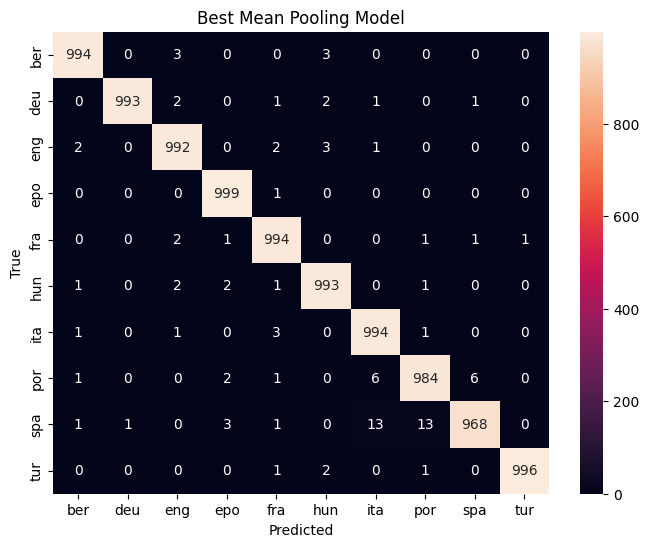

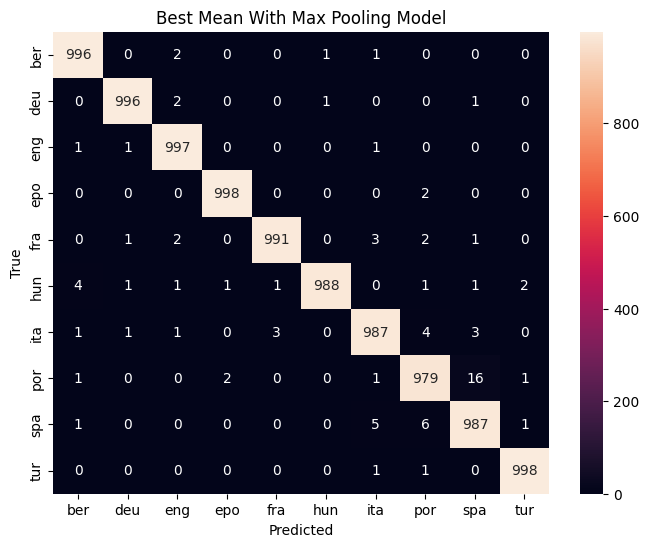

In [ ]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=[id2label[i] for i in range(len(labels))],
        yticklabels=[id2label[i] for i in range(len(labels))],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


plot_confusion(best_mean_run["dev_labels"], best_mean_run["dev_preds"], "Best Mean Pooling Model")
plot_confusion(best_mean_max_run["dev_labels"], best_mean_max_run["dev_preds"], "Best Mean With Max Pooling Model")


In [ ]:
def mcnemar_test_between_runs(run_a, run_b, name_a="mean", name_b="mean_max"):
    y_true_a = run_a["dev_labels"]
    y_true_b = run_b["dev_labels"]

    if not np.array_equal(y_true_a, y_true_b):
        raise ValueError("The dev label order is not identical between the two runs.")

    correct_a = (run_a["dev_preds"] == y_true_a)
    correct_b = (run_b["dev_preds"] == y_true_b)

    both_correct = np.sum(correct_a & correct_b)
    a_only = np.sum(correct_a & ~correct_b)
    b_only = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)

    table = [[both_correct, a_only], [b_only, both_wrong]]

    test_result = mcnemar(
        table,
        exact=(a_only + b_only < 25),
        correction=(a_only + b_only >= 25),
    )

    print(f"McNemar contingency table ({name_a} vs {name_b}):")
    print(pd.DataFrame(
        table,
        index=[f"{name_a} correct", f"{name_a} wrong"],
        columns=[f"{name_b} correct", f"{name_b} wrong"],
    ))

    print("\nInterpretation:")
    print(f"- {name_a} only correct: {a_only}")
    print(f"- {name_b} only correct: {b_only}")
    print(f"- p-value: {test_result.pvalue:.6f}")

    if test_result.pvalue < 0.05:
        print("Result: statistically significant difference at alpha = 0.05")
    else:
        print("Result: not statistically significant at alpha = 0.05")

    return table, test_result


mcnemar_table, mcnemar_result = mcnemar_test_between_runs(
    best_mean_run,
    best_mean_max_run,
    name_a="mean",
    name_b="mean_max",
)


McNemar contingency table (mean vs mean_max):
              mean_max correct  mean_max wrong
mean correct              9868              39
mean wrong                  49              44

Interpretation:
- mean only correct: 39
- mean_max only correct: 49
- p-value: 0.337356
Result: not statistically significant at alpha = 0.05


In [ ]:
summary_idx = summary_df.set_index("pooling")

mean_f1 = summary_idx.loc["mean", "macro_f1_mean"]
mean_acc = summary_idx.loc["mean", "accuracy_mean"]
meanmax_f1 = summary_idx.loc["mean_max", "macro_f1_mean"]
meanmax_acc = summary_idx.loc["mean_max", "accuracy_mean"]

print("!!! FINAL COMPARISON !!!")
print(f"Mean pooling | avg macro-F1 = {mean_f1:.6f} | avg accuracy = {mean_acc:.6f}")
print(f"Mean with max pooling | avg macro-F1 = {meanmax_f1:.6f} | avg accuracy = {meanmax_acc:.6f}")
print(f"McNemar p-value on best models = {mcnemar_result.pvalue:.6f}")

if (meanmax_f1 > mean_f1) and (meanmax_acc >= mean_acc):
    if mcnemar_result.pvalue < 0.05:
        print("\nRecommendation: USE MEAN WITH MAX POOLING.")
        print("Reason: it improved performance and the best-model difference is statistically significant.")
    else:
        print("\nRecommendation: LEAN TOWARD MEAN WITH MAX POOLING.")
        print("Reason: it improved average performance, but the best-model difference was not statistically significant.")
elif (mean_f1 > meanmax_f1) and (mean_acc >= meanmax_acc):
    if mcnemar_result.pvalue < 0.05:
        print("\nRecommendation: KEEP MEAN POOLING ONLY.")
        print("Reason: it performed better and the best-model difference is statistically significant.")
    else:
        print("\nRecommendation: LEAN TOWARD MEAN POOLING ONLY.")
        print("Reason: it performed better on average, but the best-model difference was not statistically significant.")
else:
    print("\nRecommendation: RESULTS ARE MIXED.")
    print("Reason: one method won on one metric and lost on another. In that case, prefer macro-F1 and inspect confusion matrices.")


!!! FINAL COMPARISON !!!
Mean pooling | avg macro-F1 = 0.990691 | avg accuracy = 0.990700
Mean with max pooling | avg macro-F1 = 0.991700 | avg accuracy = 0.991700
McNemar p-value on best models = 0.337356

Recommendation: LEAN TOWARD MEAN WITH MAX POOLING.
Reason: it improved average performance, but the best-model difference was not statistically significant.


In [ ]:
output_dir = Path("/content/drive/MyDrive/Penn State/tatoeba_audit_output/pooling_experiment_results")
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "per_run_results.csv", index=False)
summary_df.to_csv(output_dir / "summary_results.csv", index=False)

# this instructs it to save the best-run prediction results
pd.DataFrame({
    "text": best_mean_run["dev_texts"],
    "true_label": [id2label[i] for i in best_mean_run["dev_labels"]],
    "pred_mean": [id2label[i] for i in best_mean_run["dev_preds"]],
    "pred_mean_max": [id2label[i] for i in best_mean_max_run["dev_preds"]],
}).to_csv(output_dir / "best_run_predictions_comparison.csv", index=False)

with open(output_dir / "experiment_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2)

print(f"Saved outputs to: {output_dir}")


Saved outputs to: /content/drive/MyDrive/Penn State/tatoeba_audit_output/pooling_experiment_results
